# QFTD_WithSignRecovery.ipynb
Jordan Cioni, 2026

### Imports

In [1]:
# Starting timer
import time
time_0t = time.time()

# General Inports
import numpy as np
import matplotlib.pyplot as plt

# Qiskit Imports
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import UnitaryGate, HGate
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit.primitives import StatevectorSampler as Sampler

# Setting Figure Font
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Computer modern']})
rc('text', usetex=True)



### Execution Parameters

In [2]:
# Number of shots
num_shots = 10**7

# Number of qubits
n = 6

# Number of samples
Samples = 2**n

### Input Function

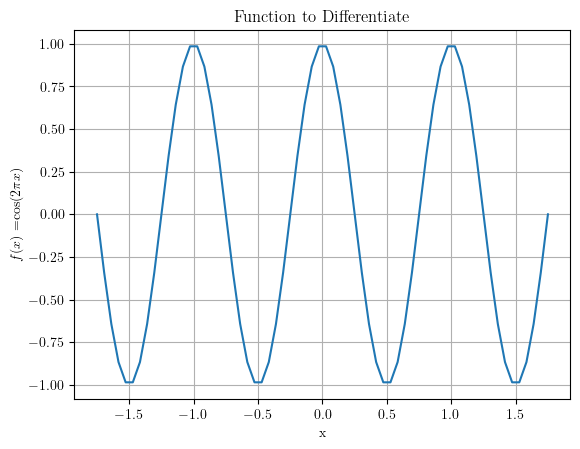

In [3]:

# f(x) = cos(2pix)
x = np.linspace(-1.75, 1.75, Samples)
fx = np.cos(2*np.pi*x)
Fx = -2*np.pi*np.sin(2*np.pi*x)  
str_fx = r'$\cos(2\pi x)$'


# # f(x) = 1/x
# x = np.linspace(-1, 1, Samples)
# fx = 1/x
# Fx = -1*x**(-2) 
# str_fx = r'$1/x$'


# # f(x) = 1/x
# x = np.linspace(0.2, 1, Samples)
# fx = 1/x
# Fx = -1*x**(-2) 
# str_fx = r'$1/x$'


# # f(x) = x^3 +x^2 - x
# # Recomended to remove outliers (See Cell 16)
# x=np.linspace(-1, 1, Samples)
# fx = x**3 + x**2 - x
# Fx = 3*(x**2) + 2*x - 1
# # Function strings for final analysis
# str_fx = r'$x^3 + x^2 - x$'
# str_save = 'QFTD_Signs_Poly'

# # f(x) = cos(pi/2 x) + sin(3pi/2 x)
# # Recomended to remove outliers (See Cell 16)
# x=np.linspace(-2, 2, Samples)
# fx = np.cos(np.pi*x/2) + np.sin(3*np.pi*x/2)
# Fx = -np.pi*np.sin(np.pi*x/2)/2 +3*np.pi*np.cos(3*np.pi*x/2)/2
# # Function strings for final analysis
# str_fx = r'$\cos(\pi x / 2) + \sin(3\pi x / 2)$'
# str_save = 'QFTD_Signs_MultipleTrig'



# Plotting Function
plt.plot(x,fx);
plt.xlabel('x');
plt.ylabel(f'{r'$f(x) = $'}{str_fx}');
plt.grid()
plt.title('Function to Differentiate');

### Normalizing Input Vector and Finding Scaling Info

In [4]:
# Getting Norm
Norm = np.sqrt(np.sum(fx**2))

# Normalizing fx
fx = fx/Norm

# Getting deltaX
deltaX = (x[-1]-x[0])/Samples

# Getting Resolution
Res = (1/(10**7))*((Norm/deltaX)**2)



***
# Creating Circuit

### Constructing Registers

In [5]:
# Constructing Registers
k = QuantumRegister(n, 'k')
a = QuantumRegister(1, 'a')
b = QuantumRegister(1, 'b')

### Constructing QFT Circuit

In [6]:
# Initializing QFT circuit
qft_circ = QuantumCircuit(k)

# Iterating through target bits
for target in range(n-1, -1, -1):
    
    # Apply hadamard gate to target
    qft_circ.h(k[target])
    
    # Iterate through controll qubits to 0
    for control in range(target-1,-1,-1):
        
        # Calculate r for controlled rotation
        r = target-control+1
        
        # Apply controlled phase (or rotation)
        qft_circ.cp(-2*np.pi/2**r, k[control], k[target])

# Swap qubits
for qubit in range(n//2):
    qft_circ.swap(qubit, n-qubit-1)

# # Drawing QFT Circuit
# fig, axs = plt.subplots(ncols=1, nrows=1, layout="constrained", figsize=(6, 3))
# qft_circ.draw('mpl', ax = axs)

### Converting QFT Circuit to Gates

In [7]:
# Converting QFT Circuit to a Gate
qft = qft_circ.to_gate()
qft.label = "QFT"

# Creating Controlled IQFT Gate
iqft = qft.inverse()
iqft.label = "IQFT"

# Setting IQFT control state
c_iqft1 = iqft.control(1, ctrl_state = '1')

### Constructing Wavenumber Rotation Circuit

In [8]:
# Initializing WaveNumber Rotation circuit
WaveNumber_circ = QuantumCircuit(k, a)

# Performing controlled rotations to apply sin term(s)
for target in range(n):
    r = n-target
    # Appending rotation gates
    WaveNumber_circ.crx(-2*(2*np.pi/2**r), k[target], a[:])

# Converting Wavenumber Rotation Circuit to Gate
WaveNumberRotation = WaveNumber_circ.to_gate()
WaveNumberRotation.label = "Wavenumber Rotations"

# Drawing Wavenumber Rotation Circuit
# fig, axs = plt.subplots(ncols=1, nrows=1, layout="constrained", figsize=(6, 3))
# WaveNumber_circ.draw('mpl', ax = axs)

### Creating QFTD Circuit and Gate

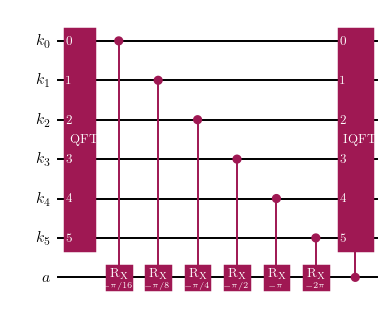

In [9]:
# Initializing circuit
qftd_circ = QuantumCircuit(k, a)

# Appending all gates
# qftd_circ.barrier(label=f"{r'$|\Psi_0\rangle$'}")
qftd_circ.append(qft, k[:])
# qftd_circ.barrier(label=f"{r'$|\Phi_0\rangle$'}")
qftd_circ.append(WaveNumberRotation, k[:]+a[:])
# qftd_circ.barrier(label=f"{r'$|\Phi_1\rangle$'}")
qftd_circ.append(c_iqft1, a[:]+k[:])
# qftd_circ.barrier(label=f"{r'$|\Psi_1\rangle$'}")

# Converting circuit to a gate
QFTD = qftd_circ.to_gate()
QFTD.label = "QFTD"

# Creating Subplots
fig, axs = plt.subplots(ncols=1, nrows=1, layout="constrained", figsize=(6, 3))
# Drawing QFTD Circuit
qftd_circ.decompose(gates_to_decompose = 'Wavenumber Rotations').draw('mpl', ax = axs)

### Building Final Circuits

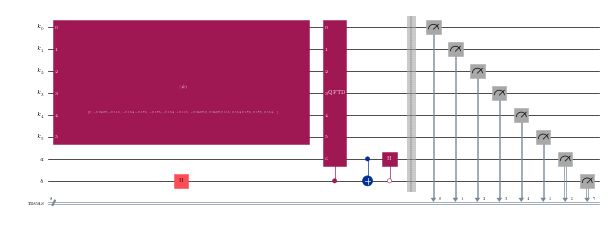

In [10]:
# Creating Quantum Circuit
qc = QuantumCircuit(k, a) # QFTD Circuit
qc_sign = QuantumCircuit(k, a, b) # QFTD Circuit With Hadamard Sign Test

# Encoding input funtion to k-register
qc.initialize(fx, k);
qc_sign.initialize(fx, k);

# Apply QFTD Gate 
qc.append(QFTD, k[:]+a[:])

# Apply Hadamards and Contolled QFTD
qc_sign.h(b[:])
qc_sign.append(QFTD.control(), b[:]+k[:]+a[:])
qc_sign.cx(a[:], b[:])
qc_sign.ch(b[:], a[:], ctrl_state='0')

# Measure all qubits
qc.measure_all()
qc_sign.measure_all()

# Creating Subplots
fig, axs = plt.subplots(ncols=1, nrows=1, layout="constrained", figsize=(6, 4))
# Drawing QFTD Circuit
qc_sign.draw('mpl', ax = axs)
# fig.savefig(f"SignRecoveryCircuit_QFTD.png", format='png', dpi=1200)

***
# Running Final Circuit

### Running Derivative Circuit

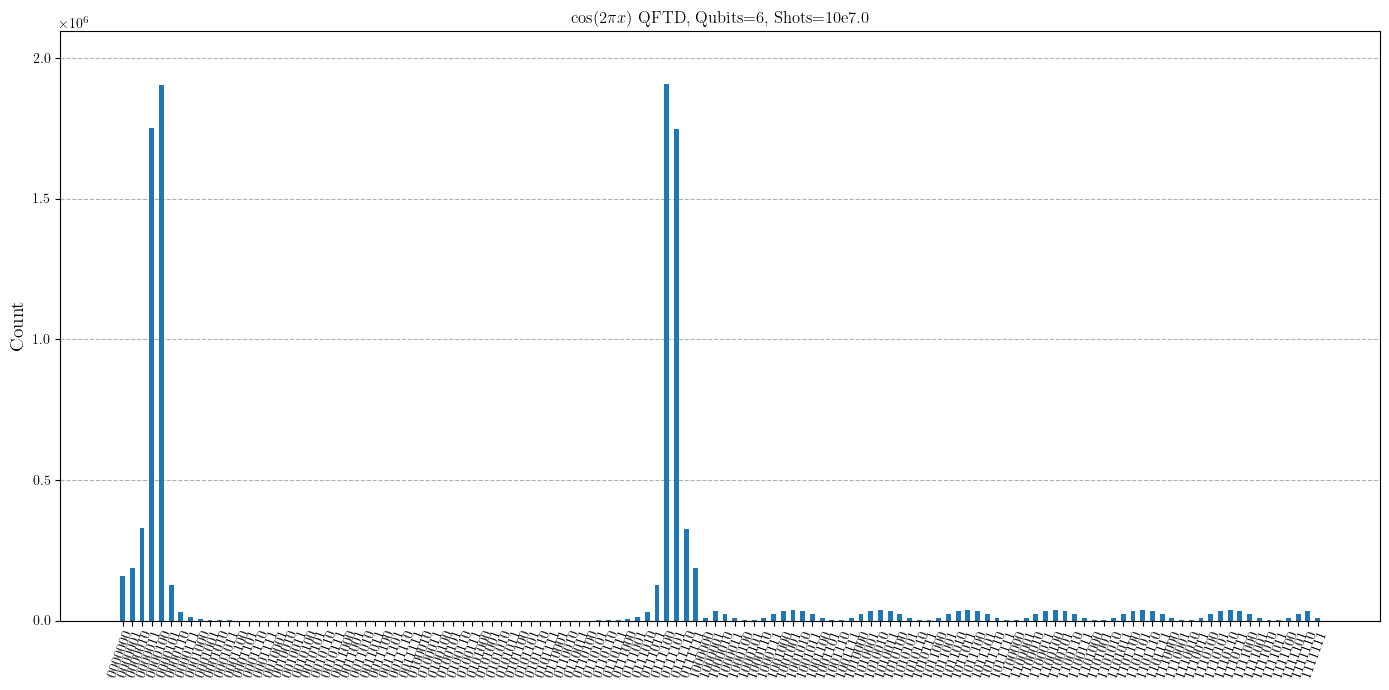

In [11]:
# Assigning a (simulator) "backend"
backend = AerSimulator(method='statevector', max_parallel_threads=14)

# Starting Execution Timer
time_0e = time.time()

# "Transpiling" the circuit
pm = generate_preset_pass_manager(3, backend)
qc_transpiled = pm.run(qc)

# Executing
final_job = backend.run(qc_transpiled, shots = num_shots)

# Getting Counts (Aer)
final_counts = final_job.result().get_counts()

# Ending Simulation Timer
ExecutionTimeString = f"Circuit Simulation Time:\t{time.time()-time_0e}"

# Plotting Results
HistogramTitle = f"{str_fx} QFTD, Qubits={n}, Shots=10e{np.log10(num_shots)}"
plot_histogram(final_counts, figsize=(14, 7), bar_labels=False, title=HistogramTitle)


### Running Sign Estimation Circuit

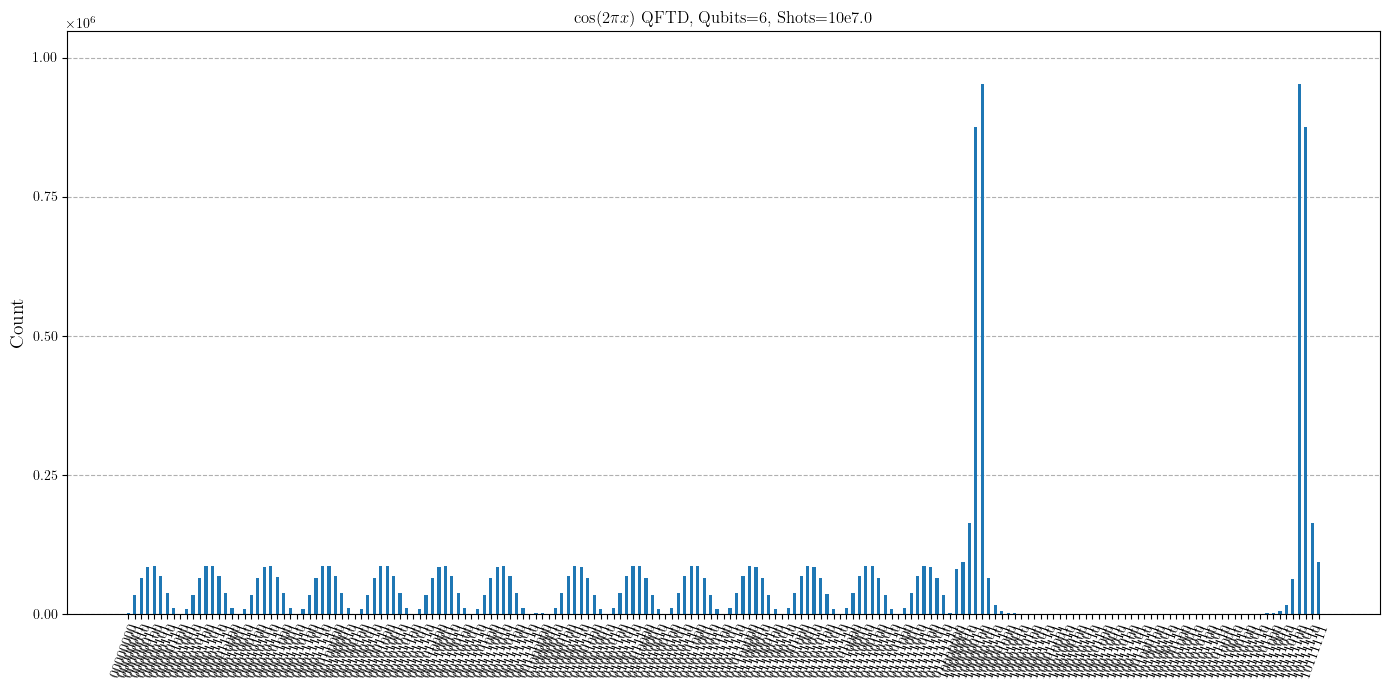

In [12]:
# Assigning a (simulator) "backend"
backend = AerSimulator(method='statevector', max_parallel_threads=14)

# "Transpiling" the circuit
pm = generate_preset_pass_manager(3, backend)
qc_transpiled = pm.run(qc_sign)

# Executing
final_job_sign = backend.run(qc_transpiled, shots = num_shots)

# Getting Counts (Aer)
final_counts_sign = final_job_sign.result().get_counts()

HistogramTitle = f"{str_fx} QFTD, Qubits={n}, Shots=10e{np.log10(num_shots)}"
plot_histogram(final_counts_sign, figsize=(14, 7), bar_labels=False, title=HistogramTitle)


***
# Evaluating Results

### Discarding measurements with ancilla in 0 state

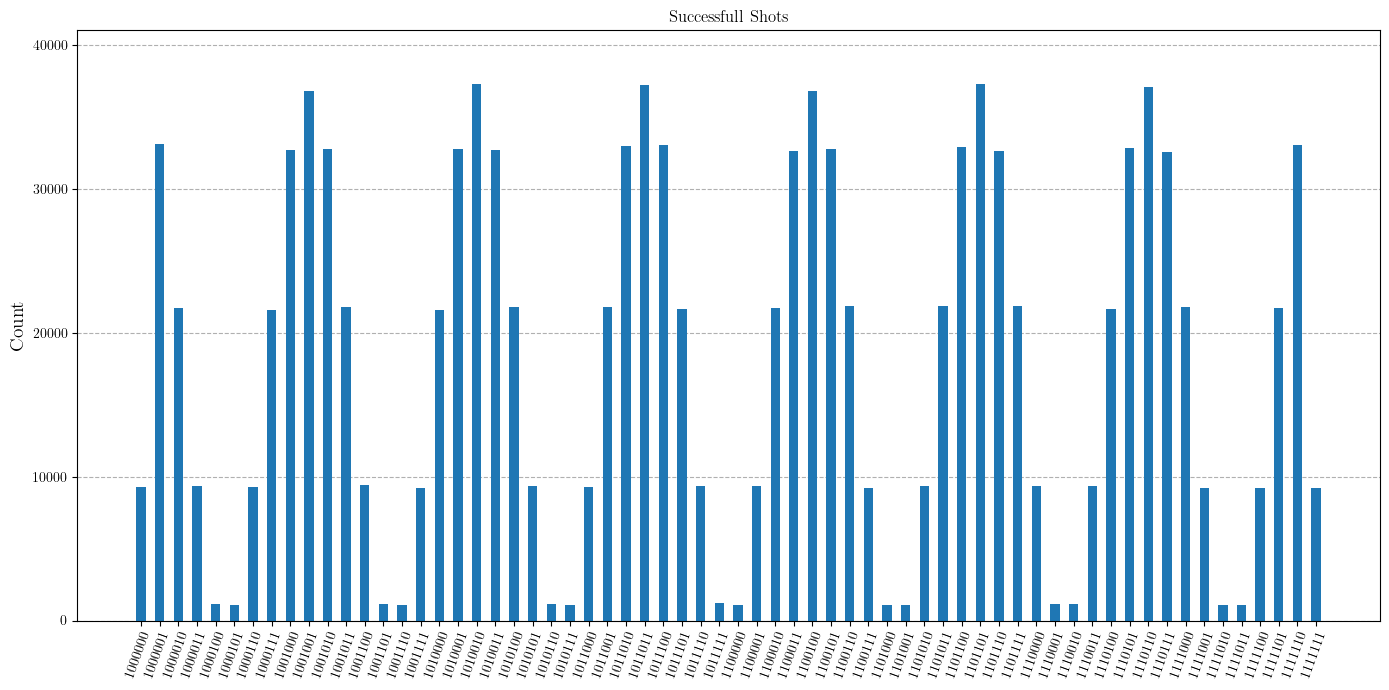

In [13]:
# Finding unsuccesfull shots (in derivative simulation)
delItem = [] # Vector of observations to remove
for key, val in final_counts.items():
    if key[0] == '0':
        delItem.append(key)

# Removing unsuccessful derivative shots
for item in delItem:
    final_counts.pop(item)

# Plotting only succesfull shots
HistogramTitle = f"Successfull Shots"
plot_histogram(final_counts, figsize=(14, 7), bar_labels=False, title=HistogramTitle)

### Processing Results into Usefull Form

In [14]:
Xout = x # Vector of X values
Yout = np.zeros((2**n)) # Associated output values
x_th = x # Theoretical x values
fx_th = fx # Theoretical funtion values
Fx_th = Fx # Theoretical derivative values


for bitstring in final_counts.keys():
    # Converting bitstring to index
    ind = int(bitstring[1:],2)
    Xout[ind] = x_th[ind]#.append(x[ind])
    Yout[ind] = final_counts[bitstring]

# Resorting all vectors
Results = np.array((Xout, Yout, x_th, fx_th, Fx_th))
Results = Results.transpose()
Results = Results[Results[:,0].argsort()].transpose()
Xout = Results[0, :]
Yout = Results[1, :]
x_th = Results[2, :]
fx_th = Results[3, :]
Fx_th = Results[4, :]



### Obtaining Sign Information By Comparing Sign Circuit Outputs

In [15]:
signs = np.ones(2**n)
Yout_Signs_Comp = np.zeros((2**n,2))
for bitstring in final_counts_sign.keys():
    # Negelect any states where b qubit is 1
    if bitstring[0] == '0': 
        # Converting bitstring to index
        ind = int(bitstring[2:],2)
        state = 0
        if bitstring[1] == '1':
            state = 1
        Yout_Signs_Comp[ind,state] = final_counts_sign[bitstring]

for ind in range(len(fx_th)):
    comp = Yout_Signs_Comp[ind,0] - Yout_Signs_Comp[ind,1]
    if fx_th[ind] > 0:
        if comp > 0:
            signs[ind] = 1
        else:
            signs[ind] = -1
    if fx_th[ind]<0:
        if comp > 0:
            signs[ind] = -1
        else:
            signs[ind] = 1



### Recovering Amplitude and Removing Outliers (If Needed)

In [16]:
# Recovering amplitude
Yout_Squared = np.divide(Yout, num_shots) * ((Norm/deltaX)**2)
Yout_Signs = np.sqrt(np.divide(Yout, num_shots) * ((Norm/deltaX)**2))*signs

# # Removing Outliers at ends (of polynomial data)
# x_th = np.delete(x_th, [0,1,-1])
# Xout = np.delete(Xout, [0,1,-1])
# Yout_Squared = np.delete(Yout_Squared, [0,1,-1])
# Yout_Signs = np.delete(Yout_Signs, [0,1,-1])
# Fx_th = np.delete(Fx_th, [0,1,-1])

# # Removing Outliers at ends (multi trig data)
# x_th = np.delete(x_th, [0,-16, -1])
# Xout = np.delete(Xout, [0,-16, -1])
# Yout_Squared = np.delete(Yout_Squared, [0,-16,-1])
# Yout_Signs = np.delete(Yout_Signs, [0,-16,-1])
# Fx_th = np.delete(Fx_th, [0,-16,-1])

### Evaluating R-Squared

In [17]:
#r2 = 1- sum[(Yactual - Yfit)^2]/sum[(Yactual-mean(Yactual))^2]

# Finding mean
meanFx_Squared = np.average(Fx_th**2)
meanFx_Signs = np.average(Fx_th)

# Finding residuals
res_Squared = Fx_th**2 - Yout_Squared
res_Signs = Fx_th - Yout_Signs

# Finding total variance
var_Squared = Fx_th**2 - meanFx_Squared
var_Signs = Fx_th - meanFx_Signs

# Finding coefficient of determination
R2_Squared = 1 - np.divide(sum(res_Squared**2), sum(var_Squared**2))
R2_Signs = 1 - np.divide(sum(res_Signs**2), sum(var_Signs**2))

# Printing Result
print(f"R^2 = {R2_Squared} (squared)")
print(f"R^2 = {R2_Signs} (signed)")


R^2 = 0.8599046583602523 (squared)
R^2 = 0.8621345671092231 (signed)


***
# Outputs

### Plotting Squared Results

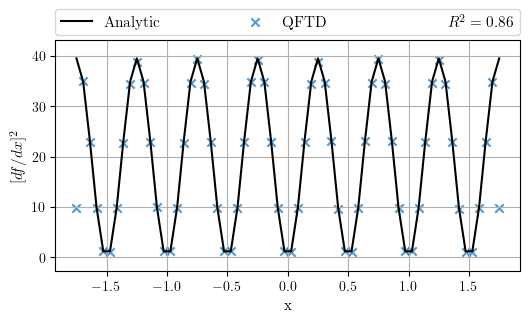

In [18]:
# Y Limits
Yrange = np.max(Yout_Squared)-np.min(Yout_Squared)
ylim0 = -Yrange*0.10 + np.min(Yout_Squared)
ylim1 = Yrange*0.10 + np.max(Yout_Squared)

# Creating Figure
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(6, 3))

# Plotting Analytical Derivative
TruDerivative = axs.plot(x, Fx**2, color='black', label='Analytic')
# Plotting Quantum Results
QftDerivative = axs.scatter(Xout, Yout_Squared, alpha=0.75, label='QFTD', marker = 'x')
# Dummy plot to include r-squared in legend
R2Text = axs.scatter([],[], marker = 'none', label=f'$R^2 = {np.round(R2_Squared, 3)}$')

# Formatting plot
axs.grid()
axs.set_xlabel('x', fontsize = 11)
axs.set_ylabel(r'$[d f /d x]^2$', fontsize = 11)
axs.set_ylim(ylim0, ylim1)
axs.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left', ncols=3, mode="expand", borderaxespad=0., fontsize=11);


### Results with (possible) Sign Recovery

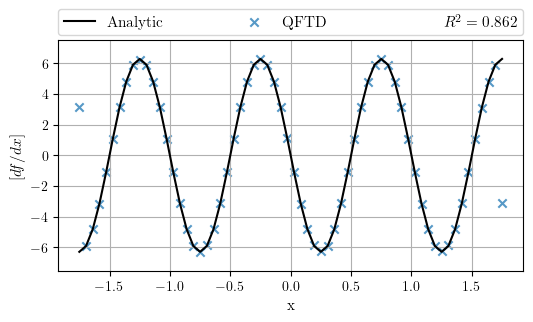

In [19]:
# Y Limits
Yrange = np.max(Yout_Signs)-np.min(Yout_Signs)
ylim1 = Yrange*0.10 + np.max(Yout_Signs)
ylim0 = -Yrange*0.10 + np.min(Yout_Signs)

# Creating Figure
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(6, 3))

# Plotting Analytical Derivative
TruDerivative = axs.plot(x_th, Fx_th, color='black', label='Analytic')
# Plotting Quantum Results
QftDerivative = axs.scatter(Xout, Yout_Signs, alpha=0.75, label='QFTD', marker = 'x')
# Dummy plot to include r-squared in legend
R2Text = axs.scatter([],[], marker = 'none', label=f'$R^2 = {np.round(R2_Signs, 3)}$')

# Formatting plot
axs.grid()
axs.set_xlabel('x', fontsize = 11)
axs.set_ylabel(r'$[d f /d x]$', fontsize = 11)
axs.set_ylim(ylim0, ylim1)
axs.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left', ncols=3, mode="expand", borderaxespad=0., fontsize=11);

# Saving plot
# fig.savefig(f"SignRecovery_cos2piX_Nq{n}Ns10e{np.log10(num_shots)}.png", format='png', dpi=1200, bbox_inches='tight')

### Execution Time

In [20]:
# Getting Total Time
TotalTimeString = f"Total Time:\t{time.time()-time_0t}"

# Printing to window
print(TotalTimeString)
print(ExecutionTimeString)

Total Time:	19.713004112243652
Circuit Simulation Time:	4.979693174362183


### Saving Data

In [21]:
# # Saving Data
# np.savez(f"{str_save}_Nq{n}_Ns10e{round(np.log10(num_shots))}_Data.npz", 
#          R2_Squared = R2_Squared, Yout_Squared = Yout_Squared,
#          R2_Signs = R2_Signs, Yout_Signs = Yout_Signs,
#          Norm = Norm, Xout = Xout, Fx_th = Fx_th, str_fx = str_fx, deltaX=deltaX)
# Data = np.load(f"{str_save}_Nq{n}_Ns10e{round(np.log10(num_shots))}_Data.npz")